In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from utils.cub_config import Config
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
from PIL import Image
from torchvision import models, transforms
import cv2 
from skimage.transform import resize
import matplotlib.pyplot as plt
import os
from utils.cub_config import Config
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model_path = Config.MODEL
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 200)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

Usando dispositivo: cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

100%|██████████| 128/128 [00:46<00:00,  2.76it/s]


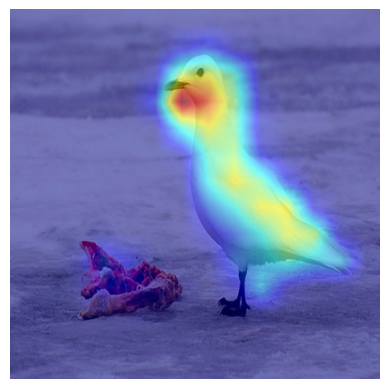

In [5]:
image_path = '../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0037_49068.jpg'
img = Image.open(image_path).convert('RGB')
input_tensor = transform(img).unsqueeze(0).to(device)

target_layer = model.layer4[-1]
cam = ScoreCAM(model=model, target_layers=[target_layer])
targets = [ClassifierOutputTarget(26)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
grayscale_cam = grayscale_cam / grayscale_cam.max()


rgb_img = np.array(img.resize((448, 448))) / 255.0
vis = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.imshow(vis)
plt.axis('off')
plt.show()

## AVALIAÇÃO

In [4]:
test_images = [
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0077_49051.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0099_49218.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0037_49068.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0118_49191.jpg",
]

In [ ]:
target_layer = model.layer4[-1]
cam = ScoreCAM(model=model, target_layers=[target_layer])
targets = [ClassifierOutputTarget(62)]



NameError: name 'model' is not defined

In [7]:
heatmaps = []
for image_path in test_images:
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0)#.to(device)

    preds = model(input_tensor)
    pred_class = torch.argmax(preds, dim=1).item()
    print(f"Predicted class: {pred_class}")

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam = grayscale_cam / grayscale_cam.max()
    heatmaps.append(grayscale_cam)

Predicted class: 62


100%|██████████| 128/128 [10:14<00:00,  4.80s/it]


Predicted class: 62


100%|██████████| 128/128 [10:39<00:00,  5.00s/it]


Predicted class: 62


100%|██████████| 128/128 [09:51<00:00,  4.62s/it]


Predicted class: 62


100%|██████████| 128/128 [09:51<00:00,  4.62s/it]


In [9]:
from cub_eval import deletion_test

In [10]:
broken_list = []
for heatmap in heatmaps:
    
    confidences, predictions, broken = deletion_test(model, input_tensor, heatmap, 62, max_steps=3000, pixels_per_step=200)
    if broken is not None:
        broken_list.append(broken)
    
    print(f"Broken at step: {broken}")

print(f"Average broken step: {np.mean(broken_list)}")

Broken at step: 248
Broken at step: 268
Broken at step: 186
Broken at step: 3
Average broken step: 176.25


In [ ]:
## plot confidences

plt.plot(confidences)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')

In [ ]:
plt.plot(predictions)
plt.title('Deletion Test')

## ROBUSTNESS

In [7]:
from cub_eval import robustness_test
robustness_scores = []
for image_path in test_images:
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0)


    robustness_score = robustness_test(model, 'ScoreCAM', input_tensor, cam, targets)
    print(f"Robustness score: {robustness_score}")
    robustness_scores.append(robustness_score)

print(f"Average robustness score: {np.mean(robustness_scores)}")

100%|██████████| 128/128 [00:11<00:00, 10.97it/s]


Robustness score: 0.9943618774414062


100%|██████████| 128/128 [00:11<00:00, 11.00it/s]


Robustness score: 0.989726185798645


100%|██████████| 128/128 [00:11<00:00, 10.72it/s]


Robustness score: 0.962007999420166


100%|██████████| 128/128 [00:12<00:00, 10.64it/s]

Robustness score: 0.9898273348808289
Average robustness score: 0.9839808344841003


## SPARSITY AND SPATIAL COHERENCE

In [11]:
from cub_eval import calculate_gini_index, calculate_spatial_coherence
from skimage.measure import label

gini_list = []
coherence_list = []
for heatmap in heatmaps:
    grayscale_cam = heatmap
    gini_index = calculate_gini_index(grayscale_cam)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)

    coherence = calculate_spatial_coherence(grayscale_cam)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print(f"Average Gini Index: {np.mean(gini_list)}")
print(f"Average Spatial Coherence: {np.mean(coherence_list)}")

Gini Index: 0.8413726091384888
Spatial Coherence: 0.9795100688934326
Gini Index: 0.769612193107605
Spatial Coherence: 0.9896957874298096
Gini Index: 0.8281103372573853
Spatial Coherence: 0.8188878297805786
Gini Index: 0.8864933848381042
Spatial Coherence: 1.0
Average Gini Index: 0.8313971161842346
Average Spatial Coherence: 0.9470233917236328


## INTRA-CLASS CONSISTENCY

In [ ]:
test_images_26 = [
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0085_796839.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0035_796837.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0034_796849.jpg",
]

In [ ]:
heatmaps = []
for image_path in test_images_26:
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0)

    target_layer = model.layer4[-1]
    cam = ScoreCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(26)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam = grayscale_cam / grayscale_cam.max()


    rgb_img = np.array(img.resize((448, 448))) / 255.0
    vis = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.imshow(vis)
    plt.axis('off')
    plt.show()
    plt.close()
    heatmaps.append(grayscale_cam)

In [12]:
from cub_eval import intraclass_consistency

consistency = intraclass_consistency(heatmaps)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.23882863646983254
